These are *recommended* solutions - many solutions may exist that all qualify for maximum points.

Always comment on your observations and results. This is partly omitted from the recommended solution here - but during the exam you should always intrepret and reflect upon your observations/results.

# Question 1

## A

In [ ]:
# (i) Define the exponential decay function
def decay(A, k, t):
    """Return A * exp(-k * t) for each t in the list."""
    return [A * math.exp(-k * ti) for ti in t]

In [ ]:
# (ii) Use the function with given inputs and print rounded results
import math

A = 100
k = 0.3
t_values = [0, 1, 2, 3, 4, 5]

vals = decay(A, k, t_values)
print([round(x, 2) for x in vals])

[100.0, 74.08, 54.88, 40.66, 30.12, 22.31]


Higher k → steeper decline.
When k increases, future values get smaller while f(0)=A remains unchanged.

In [ ]:
# (iii) Compute results for multiple scenarios and print the last value for each
scenarios = {"Low": 0.1, "Medium": 0.3, "High": 0.6}
results = {name: decay(A, rate, t_values) for name, rate in scenarios.items()}

print(" | ".join(f"{name}: {results[name][-1]:.2f}" for name in scenarios.keys()))

Low: 60.65 | Medium: 22.31 | High: 4.98


The final (last) value is lowest for the High discount rate.
Ordering: High < Medium < Low, consistent with stronger discounting.

In [ ]:
# (iv) Simulate noisy observations for the Medium case
import random

A = 100
k = 0.3
t_sim = [i * 0.05 for i in range(100)]

random.seed(42)
y_obs = [A * math.exp(-k * ti) + random.gauss(0, 2) for ti in t_sim]

pairs10 = list(zip(t_sim, y_obs))[:10]
print([(round(t, 2), round(y, 2)) for t, y in pairs10])

[(0.0, 99.71), (0.05, 98.17), (0.1, 96.82), (0.15, 97.0), (0.2, 93.92), (0.25, 89.78), (0.3, 92.06), (0.35, 89.5), (0.4, 88.26), (0.45, 87.6)]


Noise adds random variation around the smooth exponential curve.
The effect becomes more visible at later times where the signal is weaker.

In [ ]:
# (v) Estimate A by least squares with k fixed at 0.3
w = [math.exp(-k * ti) for ti in t_sim]
num = sum(yi * wi for yi, wi in zip(y_obs, w))
den = sum(wi * wi for wi in w)
A_hat = num / den
print(f"{A_hat:.3f}")

100.060


The estimate A_hat is close to 100 (true value).
Small deviations occur because of random noise, but the estimate remains reasonable.

## B

In [ ]:
# (i) Mean return per asset
import numpy as np

R = np.array([
    [ 0.010,  0.015, -0.002,  0.005],
    [ 0.005, -0.004,  0.012,  0.009],
    [-0.006,  0.008,  0.010, -0.003]
])

mu = R.mean(axis=1)
print(np.round(mu, 4))

[0.007  0.0055 0.0023]


Means are computed row-wise (assets are rows, days are columns).

In [ ]:
# (ii) Center each asset by its own mean (broadcasting)
R_centered = R - mu[:, None]
print("Row means after centering:", np.round(R_centered.mean(axis=1), 10))

Row means after centering: [-0.  0. -0.]


Broadcasting with mu[:, None] subtracts each asset’s mean from its row.
Resulting row means are ~0 (up to floating-point error).

In [ ]:
# (iii) Sample covariance matrix Σ = (1/(T-1)) R_centered R_centered^T
T = R.shape[1]
Sigma = (R_centered @ R_centered.T) / (T - 1)
print(np.round(Sigma, 6))

[[ 5.3e-05 -4.8e-05 -1.3e-05]
 [-4.8e-05  4.8e-05 -6.0e-06]
 [-1.3e-05 -6.0e-06  6.3e-05]]


This is the unbiased row-by-row covariance across the 4 days (T=4).

In [ ]:
# (iv) Solve Σ x = μ
x = np.linalg.solve(Sigma, mu)
print(np.round(x, 3))

[4.318245e+09 4.424937e+09 1.303071e+09]


x points in the direction of Σ^{-1} μ; it is proportional to mean-variance optimal weights (before normalization).


In [ ]:
# (v) Normalize x to portfolio weights and compute expected return and variance
w = x / x.sum()
E_rp = float(w @ mu)
Var_rp = float(w @ Sigma @ w)

print("w:", np.round(w, 6))
print("E[r_p]:", np.round(E_rp, 6))
print("Var(r_p):", np.round(Var_rp, 6))

w: [0.429836 0.440456 0.129707]
E[r_p]: 0.005723
Var(r_p): 0.0


Weights tilt toward assets with higher mean per unit covariance.
With very few observations, Σ can make variance appear extremely small - interpret with caution (small-sample artifact).


# Question 2

## A

In [1]:
import pandas as pd
import numpy as np

# (i) Load dataset and confirm structure
df = pd.read_csv("MLFin_Shrinkage_Test.csv")
print("Shape:", df.shape)

num_numeric = df.select_dtypes(include=[np.number]).shape[1]
print("Number of numeric variables:", num_numeric)

print("Total missing values:", df.isna().sum().sum())


FileNotFoundError: [Errno 2] No such file or directory: 'MLFin_Shrinkage_Test.csv'

Check that the dataset size is reasonable and consistent with expectations.  
All predictors should be numeric with zero missing values; otherwise,
encoding or imputation would be needed before modeling.

In [ ]:
# (ii) Summary statistics for representatives + target
representatives = ["VAL01", "MOM01", "QLT01", "SIZ01", "RSK01", "y"]
summary_rep = df[representatives].describe().T[['mean','std']]
print("Summary statistics of representative variables and target:")
display(summary_rep)

Summary statistics of representative variables and target:


,mean,std
VAL01,9.237056e-17,1.000500
MOM01,-2.131628e-16,1.000500
QLT01,-2.131628e-17,1.000500
SIZ01,-7.815970e-17,1.000500
RSK01,2.842171e-17,1.000500
y,3.861668e-02,1.524481


Look for roughly standardized predictors (means near 0, std near 1).  
Large deviations may indicate unscaled features or outliers.  
The target’s variation shows the overall prediction difficulty.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# (iii) Prepare feature matrix, train-test split, and baseline OLS
X = df.drop(columns="y").values
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ols = LinearRegression()
ols.fit(X_train, y_train)

mse_train = mean_squared_error(y_train, ols.predict(X_train))
mse_test = mean_squared_error(y_test, ols.predict(X_test))

print(f"OLS MSE — train: {mse_train:.4f}, test: {mse_test:.4f}")

OLS MSE — train: 1.4027, test: 1.5750


Compare train and test MSEs: large gaps suggest overfitting, while similar
values indicate stable generalization. Shrinkage methods can help reduce
variance if test error is noticeably higher than training error.

## B

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error

# (i) LassoCV with 5-fold cross-validation
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(cv=5, random_state=42))
])
lasso_pipe.fit(X_train, y_train)

lasso_model = lasso_pipe.named_steps["model"]
lambda_lasso = lasso_model.alpha_

y_pred = lasso_pipe.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred)

print(f"Selected penalty: {lambda_lasso:.6g}")
print(f"Lasso test MSE: {mse_test:.4f}")


Selected penalty: 0.0172954
Lasso test MSE: 1.5667


Check if the chosen λ is reasonable (not too large or too small).  
A higher λ indicates stronger regularization and more shrinkage.  
Compare test MSE with OLS: lower MSE suggests improved generalization.

In [ ]:
# (ii) Number of selected predictors
predictors = df.drop(columns="y").columns
coefs = pd.Series(lasso_model.coef_, index=predictors)
n_selected = np.sum(lasso_model.coef_ != 0)
print(f"Number of predictors selected (non-zero): {n_selected}")

Number of predictors selected (non-zero): 21


Observe how many predictors remain non-zero.  
A smaller number indicates sparsity and that Lasso effectively removed weaker signals.

In [ ]:
# (iii) Identify selected predictors and feature groups
selected_vars = coefs[coefs != 0]
print("\nSelected predictors:")
print(selected_vars)


Selected predictors:
VAL01    0.553142
VAL03   -0.162663
VAL06   -0.057208
VAL07   -0.002813
VAL10    0.040480
MOM01    0.383979
MOM02    0.240131
MOM05   -0.024084
MOM07    0.152390
MOM08   -0.058321
MOM10    0.021296
QLT01    0.012630
QLT02    0.387469
QLT07   -0.229047
QLT09   -0.067969
SIZ01   -0.035607
SIZ02   -0.003524
SIZ09   -0.087608
RSK03    0.332054
RSK06   -0.042649
RSK09   -0.005048
dtype: float64


Look for which feature groups are most represented among the selected variables.  
Groups appearing more often likely contain the most predictive signals. Also look at the coefficients and their magnitudes as an indication.

## C

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error

# (i) Elastic Net with 5-fold CV (l1_ratio = α = 0.5)
elastic_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(l1_ratio=0.5, cv=5, random_state=42, max_iter=10000))
])
elastic_pipe.fit(X_train, y_train)

y_pred = elastic_pipe.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred)
print(f"Elastic Net test MSE: {mse_test:.4f}")


Elastic Net test MSE: 1.5672


Compare test MSE to OLS/Lasso: lower = better generalization; similar = comparable performance.
If unstable across folds/splits, consider adjusting l1_ratio or regularization strength.

In [ ]:
# (ii) Selected penalty parameter
elastic_model = elastic_pipe.named_steps["model"]
lambda_elastic = elastic_model.alpha_
print(f"Selected penalty (λ): {lambda_elastic:.6g}")

Selected penalty (λ): 0.0244031


Contrast λ with Lasso’s: larger λ ⇒ stronger shrinkage.
With α=0.5, λ reflects combined L1+L2 penalty; expect λ needs not match Lasso’s scale exactly.
Consistent λ across resamples suggests stable tuning.

In [ ]:
# (iii) Number of selected predictors
predictors = df.drop(columns="y").columns
coefs = pd.Series(elastic_model.coef_, index=predictors)
n_selected = int((coefs != 0).sum())
print(f"Non-zero coefficients: {n_selected}")

Non-zero coefficients: 30


Compare to Lasso’s count: Elastic Net often keeps more features when predictors are correlated (grouping effect).
If many features selected with no MSE gain, consider increasing λ or α (more L1) to improve sparsity.

## D

(i): OLS test MSE ≈ 1.5750; Lasso ≈ 1.5667; Elastic Net ≈ 1.5672.  
Lasso slightly outperforms OLS by shrinking coefficients and reducing overfitting.  
Elastic Net performs comparably, indicating that its α=0.5 mix helps stabilize correlated features.


(ii): Lasso selects 21 predictors, Elastic Net 30.  
The higher count in Elastic Net reflects the L2 component retaining correlated variables within feature groups, while Lasso enforces stronger sparsity.


(iii): Shrinkage models can still include correlated variables and bias coefficients toward zero.  
A practical improvement is Post-Lasso—refitting OLS on the selected predictors—to reduce bias and enhance interpretability.


# Question 3

## A

In [6]:
# (i) Load data and inspect structure
import pandas as pd

df =pd.read_csv("/Users/jonas/Downloads/MLFin_Trees_test.csv")

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nFirst few rows:")
print(df.head())

# Identify column types
cat_cols = ["style", "listing"]
target = "excess_7d_alpha"
num_cols = [c for c in df.columns if c not in cat_cols + [target]]

print("\nNumeric summary:")
print(df[num_cols + [target]].describe().T)

for c in cat_cols:
    print(f"\nValue counts for {c}:")
    print(df[c].value_counts(dropna=False))



Shape: (1000, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   style            947 non-null    object 
 1   listing          943 non-null    object 
 2   carry_yield      955 non-null    float64
 3   vol_of_vol       961 non-null    float64
 4   short_interest   956 non-null    float64
 5   option_skew      956 non-null    float64
 6   macro_beta       939 non-null    float64
 7   excess_7d_alpha  1000 non-null   float64
dtypes: float64(6), object(2)
memory usage: 62.6+ KB
None

First few rows:
     style listing  carry_yield  vol_of_vol  short_interest  option_skew  \
0      NaN    NYSE     0.023091    0.095526        0.026940     0.024199   
1    Value    NYSE          NaN    0.067890        0.008188    -0.186564   
2   Growth  NASDAQ     0.036231    0.065889        0.047342     0.942482   
3  Quality    NYSE     0.021718 

Dataset mixes categorical (style, listing), continuous predictors, and a continuous target (excess_7d_alpha).
Look for spread/variation in numeric summaries and level balance in categorical counts; potential group differences may appear across style/listing.

(For an exam situation, you are required to point out some specifics. For the purpose of this recommended solution, things like these have been omitted, so you can form your own opinions.)

In [7]:
# (ii) Check missing values and unusual values
import numpy as np

print("Missing values per column:")
print(df.isna().sum())

# Quick look for extreme numeric values (simple z-score check)
for col in num_cols:
    z = (df[col] - df[col].mean()) / df[col].std()
    outliers = (abs(z) > 3).sum()
    print(f"{col}: {outliers} extreme values")

# Handle missing values:
# For numeric: fill with median
# For categorical: fill with mode
df_filled = df.copy()
for col in num_cols:
    df_filled[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df_filled[col] = df[col].fillna(df[col].mode()[0])


Missing values per column:
style              53
listing            57
carry_yield        45
vol_of_vol         39
short_interest     44
option_skew        44
macro_beta         61
excess_7d_alpha     0
dtype: int64
carry_yield: 16 extreme values
vol_of_vol: 22 extreme values
short_interest: 14 extreme values
option_skew: 2 extreme values
macro_beta: 0 extreme values


Tree-based methods don’t require scaling or transformations.
Filling numeric NaNs with median and categorical with mode is simple and robust.
Winsorizing or removing outliers is not required unless values are extreme and unrealistic. Trees in general are robust to outliers, hence we skip it. Please note you could also have used the IQR approach to identify outliers here.

In [8]:
# (iii) Encode categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df_filled, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (1000, 10)


We use one-hot encoding to convert categorical variables to numeric 0/1 columns.
drop_first=True avoids perfect collinearity, and tree models handle such features naturally.

## B

In [9]:
# (i) Split into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))


Training size: 750
Test size: 250


Using random_state=42 ensures reproducibility.
A 75/25 split gives enough data for both training and testing.

In [10]:
# (ii) Baseline model: predict mean of target
from sklearn.metrics import mean_squared_error

y_pred_base = np.repeat(y_train.mean(), len(y_test))
mse_base = mean_squared_error(y_test, y_pred_base)
print("Baseline MSE:", round(mse_base, 6))


Baseline MSE: 0.009572


The baseline predicts the same mean value for all firms.
Any useful model should achieve a lower MSE than this simple benchmark.

(iii) Why cross-validation?
Cross-validation repeats the train/test process on multiple folds.
This gives a more reliable estimate of model performance than a single random split.

(iv) When cross-validation might mislead:
CV can fail when there is time-dependence or leakage (e.g., same firms appear in both train and test).
In finance, use time-aware splits or check if CV results differ strongly from a final test evaluation.


## C

In [ ]:
# (i) Train BaggingRegressor and evaluate
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,
    bootstrap=True,
    random_state=42
)
bag.fit(X_train, y_train)

# Training and validation MSE
mse_train = mean_squared_error(y_train, bag.predict(X_train))
mse_test = mean_squared_error(y_test, bag.predict(X_test))

print("Training MSE:", round(mse_train, 6))
print("Validation (Test) MSE:", round(mse_test, 6))




Training MSE: 0.000128
Validation (Test) MSE: 0.001249


If training MSE is much smaller than test MSE → overfitting.
If both are large → underfitting.

In [ ]:
# (ii) Hyperparameter tuning with GridSearchCV for BaggingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 600],
    "estimator__max_depth": [6, 12],
    "estimator__min_samples_leaf": [1, 5],
}

gcv = GridSearchCV(
    estimator=bag,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    refit=True  # refits on the full training set using the best params
)

gcv.fit(X_train, y_train)

print("Best params:", gcv.best_params_)
print("Best CV MSE:", round(-gcv.best_score_, 6))


Best params: {'estimator__max_depth': 12, 'estimator__min_samples_leaf': 1, 'n_estimators': 100}
Best CV MSE: 0.000873


We tune ensemble size (n_estimators), and tree complexity (max_depth and min_samples_leaf).
The best configuration minimizes cross-validated MSE.

You could also have used OOB here.

In [ ]:
# (iii) Retrain tuned model on full training data and evaluate on the test set
best_model = gcv.best_estimator_  # already refit on X_train by GridSearchCV
y_pred_test = best_model.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred_test)
print("Test MSE (tuned Bagging):", round(mse_test, 6))

Test MSE (tuned Bagging): 0.001244


The test MSE is our out-of-sample performance for the tuned Bagging model.

(iv) Bagging: variance and interpretability
Averaging many resampled trees lowers prediction variance (more stable, less sensitive to a single split).
Interpretability is reduced because no single tree explains the prediction.


## D

In [ ]:
# (i) Compare tuned Bagging to the baseline
# Assumes mse_base from earlier
improvement_pct = (mse_base - mse_test) / mse_base * 100
print(f"Baseline MSE: {round(mse_base, 6)}")
print(f"Bagging (tuned) MSE: {round(mse_test, 6)}")
print(f"Improvement vs baseline: {improvement_pct:.2f}%")

Baseline MSE: 0.009572
Bagging (tuned) MSE: 0.001244
Improvement vs baseline: 87.01%


Assess both statistical significance (clear MSE reduction) and practical relevance (does it matter economically for decisions/costs?).


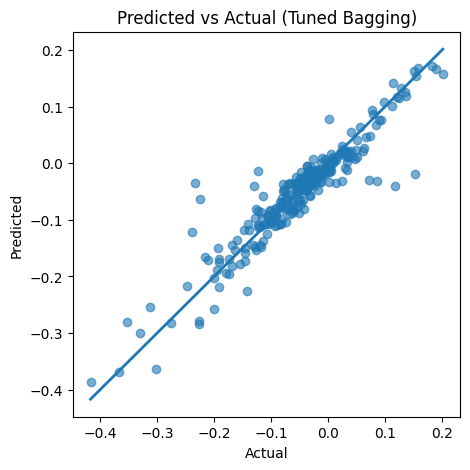

In [ ]:
# (ii) Predicted vs. actual scatter plot (test set)
import matplotlib.pyplot as plt

y_pred_test = best_model.predict(X_test)

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_test, alpha=0.6)
lo, hi = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
plt.plot([lo, hi], [lo, hi], linewidth=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Tuned Bagging)")
plt.show()

Points close to the 45° line indicate accurate predictions.
Patterns like curvature, fanning, or clusters suggest bias, heteroskedasticity, or regime effects.

(iii) Limitations and a practical mitigation:
Ensembles can overfit subtle noise and are less interpretable; finance data may be non-stationary.
Mitigate with a truly out-of-time test split, leakage checks, and stability tests (e.g., re-fit on bootstraps and compare feature importances/performance dispersion).
